# Import Libraries

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
import scanpy as sc 
import pygenelab as pgl
import decoupler as dc
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# Util Functions

In [13]:
def cliffs_delta(x, y):
    """
    calculate cliff's delta between two groups
    """

    # cliffs_delta
    # api:
    # cliffs_delta(
    #     x=om6_scores,
    #     y=om9_scores,
    # )

    # remove missing values
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    nx = len(x)
    ny = len(y)

    # return nan if either group is empty
    if nx == 0 or ny == 0:
        return float("nan")

    # rank all values together
    ranks = rankdata(list(x) + list(y))

    # get ranks for first group
    x_ranks = ranks[:nx]

    # mann-whitney u for first group
    u = x_ranks.sum() - nx * (nx + 1) / 2

    # convert u to cliff's delta
    delta = (2 * u / (nx * ny)) - 1

    return delta

In [28]:
def save_df_table_image(
    df,
    output_path=None,
    index=False,
    round_digits=4,
    font_size=10,
    row_height=0.5,
    min_col_width=0.08,
    max_col_width=0.45
):
    """
    create a dataframe table image and optionally save it
    """

    # save_df_table_image
    # api:
    # fig = save_df_table_image(
    #     df=cliffs_df,
    #     output_path="Output/cliffs_table.png",
    # )

    # copy df so original is not changed
    df_to_show = df.copy()

    # round numeric columns
    numeric_cols = df_to_show.select_dtypes(include="number").columns
    df_to_show[numeric_cols] = df_to_show[numeric_cols].round(round_digits)

    # include index if requested
    if index:
        df_to_show = df_to_show.reset_index()

    # convert everything to string for display
    df_display = df_to_show.astype(str)

    # get table shape
    nrows, ncols = df_display.shape

    # compute column widths from max text length
    col_lengths = []
    for col in df_display.columns:
        max_cell_len = df_display[col].map(len).max()
        header_len = len(str(col))
        col_lengths.append(max(max_cell_len, header_len))

    total_len = sum(col_lengths)

    # normalized widths
    col_widths = []
    for length in col_lengths:
        width = length / total_len
        width = max(min_col_width, width)
        width = min(max_col_width, width)
        col_widths.append(width)

    # renormalize so widths sum to about 1
    width_sum = sum(col_widths)
    col_widths = [w / width_sum for w in col_widths]

    # figure size
    fig_width = max(12, sum(col_lengths) * 0.18)
    fig_height = max(2.5, (nrows + 1) * row_height)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # create table
    table = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1]
    )

    # base style
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.4)

    # style cells
    for (row, col), cell in table.get_celld().items():
        # set per-column widths
        cell.set_width(col_widths[col])

        # header row
        if row == 0:
            cell.set_text_props(weight="bold")

        # left align first column for long pathway names
        if col == 0 and row > 0:
            cell.get_text().set_ha("left")
            cell.PAD = 0.01

    plt.tight_layout()

    # save only if path is provided
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

In [1]:
def calculate_score_cliffs_delta(
    adata,
    score_col,
    group_col="sample",
    group1="OM6",
    group2="OM9",
    dropna=True
):
    """
    calculate cliff's delta for one obs score column between two groups
    """

    # calculate_obs_score_cliffs_delta
    # api:
    # result_df, group_score_df = calculate_obs_score_cliffs_delta(
    #     adata=adata,
    #     score_col="GOBP_PYRUVATE_METABOLIC_PROCESS",
    #     group_col="sample",
    #     group1="OM6",
    #     group2="OM9",
    # )

    # check required columns
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} not found in adata.obs")

    if score_col not in adata.obs.columns:
        raise ValueError(f"{score_col} not found in adata.obs")

    # prepare cell-level score dataframe
    group_score_df = adata.obs[[group_col, score_col]].copy()

    # remove missing values
    if dropna:
        group_score_df = group_score_df.dropna(subset=[group_col, score_col])

    # add pathway name
    group_score_df["pathway"] = score_col

    # get group scores
    group1_scores = group_score_df.loc[
        group_score_df[group_col] == group1,
        score_col
    ]

    group2_scores = group_score_df.loc[
        group_score_df[group_col] == group2,
        score_col
    ]

    # calculate cliff's delta
    delta = cliffs_delta(
        x=group1_scores,
        y=group2_scores
    )

    # decide direction
    if delta > 0:
        higher_group = group1
    elif delta < 0:
        higher_group = group2
    else:
        higher_group = "similar"

    # store result
    result = {
        "score_col": score_col,

        f"{group1}_count": group1_scores.dropna().shape[0],
        f"{group2}_count": group2_scores.dropna().shape[0],

        f"{group1}_mean": group1_scores.mean(),
        f"{group2}_mean": group2_scores.mean(),

        f"{group1}_median": group1_scores.median(),
        f"{group2}_median": group2_scores.median(),

        f"{group1}_std": group1_scores.std(),
        f"{group2}_std": group2_scores.std(),

        f"{group1}_min": group1_scores.min(),
        f"{group2}_min": group2_scores.min(),

        f"{group1}_max": group1_scores.max(),
        f"{group2}_max": group2_scores.max(),

        "mean_difference": group1_scores.mean() - group2_scores.mean(),
        "median_difference": group1_scores.median() - group2_scores.median(),

        "cliffs_delta": delta,
        "abs_cliffs_delta": abs(delta),
        "higher_group": higher_group
    }

    # convert result to dataframe
    result_df = pd.DataFrame([result])

    return result_df, group_score_df

# Get Data

In [14]:
# female human skeletal muscle path
FEMALE_HUMAN_SKM_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad"

# load adata
adata = sc.read_h5ad(FEMALE_HUMAN_SKM_PATH)

# only keep OM6 and OM9
adata = pgl.subset_adata_by_obs(adata, filters={"sample": ["OM6", "OM9"]})
display(adata.obs["sample"].value_counts())

sample
OM9    40449
OM6    11429
Name: count, dtype: int64

# Get Genesets

In [15]:
# marked metabolic pathways
metabolic_pathways = [
    "HALLMARK_FATTY_ACID_METABOLISM",
    "HALLMARK_XENOBIOTIC_METABOLISM",
    "REACTOME_PYRUVATE_METABOLISM",
    "REACTOME_PHOSPHOLIPID_METABOLISM",
    "REACTOME_GLYCOGEN_METABOLISM",
    "REACTOME_GLYCOSAMINOGLYCAN_METABOLISM",
    "WP_PURINE_METABOLISM"
]

# mice all pathways path
MICE_ALL_PATHWAYS = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"

# Loop / Calculate Scores / Store Them As Dataframe

In [16]:
results = []
all_group_score_dfs = []

group_col = "sample"
group1 = "OM6"
group2 = "OM9"

for pathway in metabolic_pathways:

    # load pathway genes
    pathway_genes = pgl.convert_gmt_to_decoupler_format(
        MICE_ALL_PATHWAYS,
        include_pathways=[pathway],
        gene_origin="human"
    )

    # calculate aucell scores
    dc.mt.aucell(
        adata,
        pathway_genes,
        raw=False,
        verbose=True
    )

    # store scores in obs
    adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()

    # prepare cell-level score dataframe
    group_score_df = pgl.prepare_group_score_df(
        adata,
        group_col=group_col,
        value_col=pathway,
        dropna=True
    )

    # add pathway name
    group_score_df["pathway"] = pathway

    # store long score dataframe
    all_group_score_dfs.append(group_score_df)

    # get group scores
    group1_scores = group_score_df.loc[
        group_score_df[group_col] == group1,
        pathway
    ]

    group2_scores = group_score_df.loc[
        group_score_df[group_col] == group2,
        pathway
    ]

    # calculate cliff's delta
    delta = cliffs_delta(
        x=group1_scores,
        y=group2_scores
    )

    # decide direction
    if delta > 0:
        higher_group = group1
    elif delta < 0:
        higher_group = group2
    else:
        higher_group = "similar"

    # store results
    results.append({
        "pathway": pathway,

        f"{group1}_count": group1_scores.dropna().shape[0],
        f"{group2}_count": group2_scores.dropna().shape[0],

        f"{group1}_mean": group1_scores.mean(),
        f"{group2}_mean": group2_scores.mean(),

        f"{group1}_median": group1_scores.median(),
        f"{group2}_median": group2_scores.median(),

        f"{group1}_std": group1_scores.std(),
        f"{group2}_std": group2_scores.std(),

        f"{group1}_min": group1_scores.min(),
        f"{group2}_min": group2_scores.min(),

        f"{group1}_max": group1_scores.max(),
        f"{group2}_max": group2_scores.max(),

        "mean_difference": group1_scores.mean() - group2_scores.mean(),
        "median_difference": group1_scores.median() - group2_scores.median(),

        "cliffs_delta": delta,
        "abs_cliffs_delta": abs(delta),
        "higher_group": higher_group
    })

# final cliffs delta dataframe
cliffs_df = pd.DataFrame(results)

# sort strongest effects first
cliffs_df = cliffs_df.sort_values(
    "abs_cliffs_delta",
    ascending=False
).reset_index(drop=True)

# all cell-level scores together
all_group_scores_df = pd.concat(
    all_group_score_dfs,
    ignore_index=True
)

2026-05-12 10:00:29 | [INFO] aucell - Running aucell
2026-05-12 10:00:29 | [INFO] Extracted omics mat with 51878 rows (observations) and 48355 columns (features)
2026-05-12 10:00:29 | [WARNING] 6429 features of mat are empty, they will be removed
2026-05-12 10:00:31 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-12 10:00:31 | [INFO] Network has 143 unique features and 1 unique sources
2026-05-12 10:00:31 | [INFO] aucell - calculating 1 AUCs for 41926 targets across 51878 observations, categorizing features at rank=2097
100%|██████████| 51878/51878 [01:07<00:00, 770.68it/s] 
2026-05-12 10:01:38 | [INFO] aucell - done
2026-05-12 10:01:38 | [INFO] aucell - Running aucell
2026-05-12 10:01:39 | [INFO] Extracted omics mat with 51878 rows (observations) and 48355 columns (features)
2026-05-12 10:01:39 | [WARNING] 6429 features of mat are empty, they will be removed
2026-05-12 10:01:40 | [WARNING] weight not found in net.columns, adding it as:
net['weight'

In [17]:
# display cliffs df
display(cliffs_df)

,pathway,OM6_count,OM9_count,OM6_mean,OM9_mean,OM6_median,OM9_median,OM6_std,OM9_std,OM6_min,OM9_min,OM6_max,OM9_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,REACTOME_GLYCOGEN_METABOLISM,11429,40449,0.149193,0.214954,0.146161,0.212828,0.063211,0.070468,0.000000,0.000000,0.399069,0.557152,-0.065761,-0.066667,-0.512860,0.512860,OM9
1,HALLMARK_XENOBIOTIC_METABOLISM,11429,40449,0.043575,0.050609,0.043320,0.050478,0.010539,0.012345,0.005933,0.007772,0.088559,0.105197,-0.007034,-0.007157,-0.333869,0.333869,OM9
2,HALLMARK_FATTY_ACID_METABOLISM,11429,40449,0.059291,0.066537,0.058658,0.065776,0.014480,0.016619,0.010595,0.012543,0.116412,0.141642,-0.007246,-0.007117,-0.253415,0.253415,OM9
3,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,11429,40449,0.035924,0.032128,0.035400,0.031410,0.012808,0.011862,0.000785,0.000000,0.108029,0.106092,0.003796,0.003991,0.175655,0.175655,OM6
4,REACTOME_PYRUVATE_METABOLISM,11429,40449,0.089475,0.083345,0.088802,0.081713,0.030659,0.029810,0.000402,0.000000,0.213064,0.226497,0.006130,0.007090,0.119924,0.119924,OM6
5,WP_PURINE_METABOLISM,11429,40449,0.056340,0.058590,0.056286,0.058538,0.012662,0.012203,0.010823,0.012321,0.106958,0.115024,-0.002251,-0.002252,-0.101003,0.101003,OM9
6,REACTOME_PHOSPHOLIPID_METABOLISM,11429,40449,0.059377,0.061006,0.059448,0.060738,0.013692,0.012759,0.012485,0.013111,0.113196,0.120805,-0.001628,-0.001290,-0.064135,0.064135,OM9


# Output

In [23]:
plot_df = cliffs_df[["pathway", "mean_difference", "median_difference", "cliffs_delta", "higher_group"]]

In [24]:
plot_df

,pathway,mean_difference,median_difference,cliffs_delta,higher_group
0,REACTOME_GLYCOGEN_METABOLISM,-0.065761,-0.066667,-0.512860,OM9
1,HALLMARK_XENOBIOTIC_METABOLISM,-0.007034,-0.007157,-0.333869,OM9
2,HALLMARK_FATTY_ACID_METABOLISM,-0.007246,-0.007117,-0.253415,OM9
3,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,0.003796,0.003991,0.175655,OM6
4,REACTOME_PYRUVATE_METABOLISM,0.006130,0.007090,0.119924,OM6
5,WP_PURINE_METABOLISM,-0.002251,-0.002252,-0.101003,OM9
6,REACTOME_PHOSPHOLIPID_METABOLISM,-0.001628,-0.001290,-0.064135,OM9


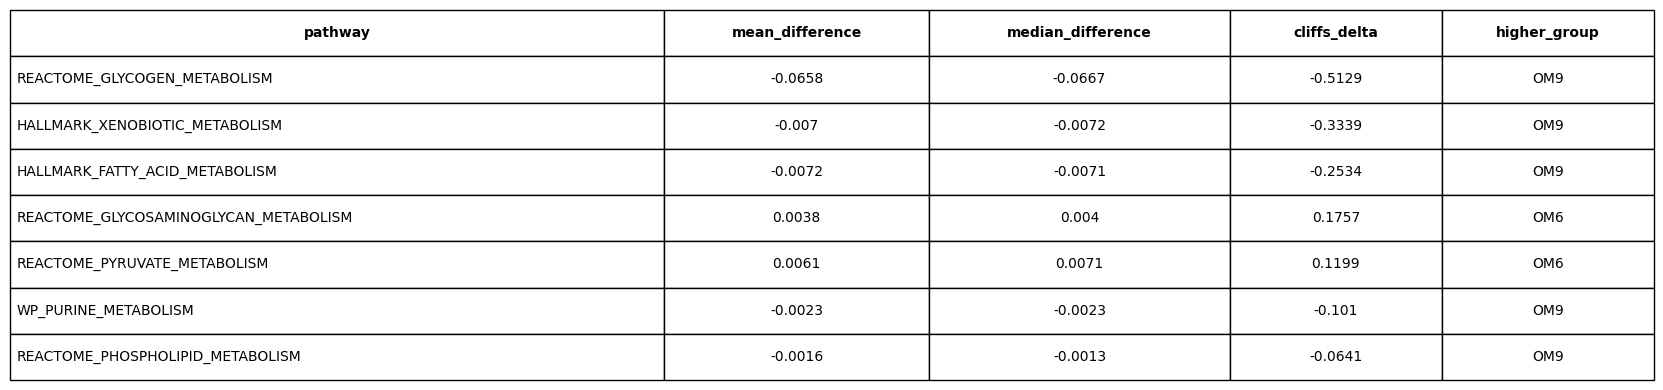

In [31]:
fig = save_df_table_image(plot_df)

In [ ]:
pgl.save_editable_svg(fig, "Output/Cliffs_Delta_SVG.svg")

PosixPath('Output/Cliffs_Delta_SVG.svg')